In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cosmic_data = pd.read_csv("data/cosmic_LI_AC_filtered.tsv",sep="\t")

In [ ]:
cosmic_data.head(5)

,GENE_SYMBOL,COSMIC_GENE_ID,TRANSCRIPT_ACCESSION,COSMIC_SAMPLE_ID,SAMPLE_NAME,COSMIC_PHENOTYPE_ID,GENOMIC_MUTATION_ID,LEGACY_MUTATION_ID,MUTATION_ID,MUTATION_CDS,...,GENOME_STOP,STRAND,PUBMED_PMID,COSMIC_STUDY_ID,HGVSP,HGVSC,HGVSG,GENOMIC_WT_ALLELE,GENOMIC_MUT_ALLELE,MUTATION_SOMATIC_STATUS
0,KCNH5,COSG64317,ENST00000394968.2,COSS2658262,T1202,COSO28864826,COSV59774556,COSM6690949,124960875,c.1164G>T,...,62950164,-,27149842.0,NaN,ENSP00000378419.1:p.Lys388Asn,ENST00000394968.2:c.1164G>T,14:g.62950164C>A,C,A,Confirmed somatic variant
1,KCNA6,COSG74209,ENST00000280684.3,COSS2812891,p12low,COSO28645307,COSV54974938,COSM5949038,105978825,c.1070G>A,...,4811111,+,31336886.0,NaN,ENSP00000280684.3:p.Arg357His,ENST00000280684.3:c.1070G>A,12:g.4811111G>A,G,A,Confirmed somatic variant
2,KCNA1,COSG107956,ENST00000382545.4,COSS2658625,T3045,COSO28864826,COSV66837919,COSM6690410,120413074,c.1126G>A,...,4912504,+,27149842.0,NaN,ENSP00000371985.3:p.Gly376Ser,ENST00000382545.4:c.1126G>A,12:g.4912504G>A,G,A,Confirmed somatic variant
3,KCNJ16,COSG79532,ENST00000392671.5,COSS1650960,TCGA-A6-6653-01,COSO28544826,COSV99388770,COSM7567238,125823795,c.584G>T,...,70132671,+,NaN,COSU376,ENSP00000376439.1:p.Gly195Val,ENST00000392671.5:c.584G>T,17:g.70132671G>T,G,T,Confirmed somatic variant
4,KCNQ2,COSG95637,ENST00000625514.2,COSS2607096,HUB-02-B2-042,COSO28864826,COSV60545683,COSN24400751,180974960,c.1187+129G>T,...,63428238,-,NaN,COSU670,NaN,ENST00000625514.2:c.1187+129G>T,20:g.63428238C>A,C,A,Confirmed somatic variant


In [6]:
cosmic_data = cosmic_data.drop_duplicates(subset = ["COSMIC_SAMPLE_ID", "GENE_SYMBOL", "MUTATION_AA"])

In [7]:
cosmic_data.sort_values(by = "MUTATION_AA")[["COSMIC_SAMPLE_ID", "GENE_SYMBOL", "MUTATION_AA"]]

,COSMIC_SAMPLE_ID,GENE_SYMBOL,MUTATION_AA
12266,COSS1651043,KCNN2,p.*232Yext*5
27533,COSS2193432,KCNK6,p.*314Lext*34
918,COSS2296184,KCNG3,p.*426=
6638,COSS2296184,KCNG3,p.*437=
4191,COSS1651043,KCNN2,p.*580Yext*5
...,...,...,...
13398,COSS2301958,KCNH4,p.Y982Tfs*24
13399,COSS2976686,KCNH4,p.Y982Tfs*24
13400,COSS1651321,KCNH4,p.Y982Tfs*24
30315,COSS2368350,KCNT1,p.Y983=


In [ ]:
DNDS_data = pd.read_csv("results/dnds_coad_COSMIC.csv")
DNDS_data.head()

,Unnamed: 0,gene_name,n_syn,n_mis,n_non,n_spl,n_ind,wmis_cv,wnon_cv,wspl_cv,...,pmis_cv,ptrunc_cv,pallsubs_cv,pind_cv,qmis_cv,qtrunc_cv,qallsubs_cv,qind_cv,pglobal_cv,qglobal_cv
0,17180,TP53,15,1076,198,61,126,32.205754,84.531254,84.531254,...,0.0,0.000000e+00,0.0,2.027192e-58,0.0,0.000000e+00,0.0,3.895451e-54,0.0,0.0
1,15262,SMAD4,11,254,35,4,16,10.247894,15.392163,15.392163,...,0.0,0.000000e+00,0.0,9.626111e-05,0.0,0.000000e+00,0.0,5.942050e-02,0.0,0.0
2,5596,FBXW7,14,268,90,10,34,8.262051,19.578148,19.578148,...,0.0,0.000000e+00,0.0,1.184860e-09,0.0,0.000000e+00,0.0,2.846034e-06,0.0,0.0
3,5881,FRG1,16,275,0,24,4,11.190325,7.258051,7.258051,...,0.0,2.996126e-10,0.0,5.298811e-02,0.0,2.214367e-07,0.0,1.000000e+00,0.0,0.0
4,5273,FAM104B,5,53,9,1,1,11.115170,14.527634,14.527634,...,0.0,9.743003e-08,0.0,3.605267e-01,0.0,4.680538e-05,0.0,1.000000e+00,0.0,0.0


In [ ]:
def sort_by_integer_column(df, column_name):
    """
    Sorts the DataFrame by the integer values found in a specified string column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to sort.

    Returns:
        pd.DataFrame: A sorted copy of the DataFrame.
    """
    # Extract the first integer from the string
    def extract_int(s):
        match = re.search(r'\d+', str(s))
        return int(match.group()) if match else float('inf')

    # Create a temporary column with extracted integers
    df['_sort_key'] = df[column_name].apply(extract_int)

    # Sort by the extracted integers and drop the temporary column
    sorted_df = df.sort_values('_sort_key').drop(columns=['_sort_key'])

    return sorted_df


In [11]:
DNDS_data[DNDS_data["gene_name"]=="KCNA5"]

,Unnamed: 0,gene_name,n_syn,n_mis,n_non,n_spl,n_ind,wmis_cv,wnon_cv,wspl_cv,...,pmis_cv,ptrunc_cv,pallsubs_cv,pind_cv,qmis_cv,qtrunc_cv,qallsubs_cv,qind_cv,pglobal_cv,qglobal_cv
173,7956,KCNA5,29,103,0,0,1,2.065492,0.0,0.0,...,0.000111,0.092586,0.000055,0.851734,0.022432,0.676833,0.009088,1.0,0.000513,0.056453


In [14]:
gene_list = [
"KCNMA1",
"KCNN2","KCNN3","KCNN4",
"KCNK3","KCNK9","KCNK12",
"KCNA5","KCNA6",
"KCNB1","KCNB2",
"KCND1",
"KCNG4",
"KCNQ1", "KCNQ4",
"KCNH1"
]


DNDS_kc = DNDS_data[DNDS_data["gene_name"].isin(gene_list)]

kcsorted = sort_by_integer_column(DNDS_kc, "gene_name")

/tmp/ipykernel_2043746/4028992947.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['_sort_key'] = df[column_name].apply(extract_int)


In [15]:
kcsorted[["gene_name", "n_syn", "n_mis", "wmis_cv","pmis_cv"]]



,gene_name,n_syn,n_mis,wmis_cv,pmis_cv
3137,KCNMA1,36,95,1.380986,0.078267
16162,KCND1,13,38,1.154433,0.613277
9317,KCNB1,33,92,1.299871,0.166775
6501,KCNH1,30,90,1.315524,0.160886
12345,KCNQ1,17,39,1.198727,0.493672
358,KCNN2,29,34,0.654358,0.081661
3276,KCNB2,47,107,1.210207,0.254318
117,KCNN3,28,91,1.660949,0.009712
5056,KCNK3,15,40,1.507744,0.126584
8210,KCNG4,29,58,1.155515,0.501101


In [17]:
kcsorted.head()
significant = kcsorted[kcsorted["pmis_cv"] < 0.05]
print(significant)

      Unnamed: 0 gene_name  n_syn  n_mis  n_non  n_spl  n_ind   wmis_cv  \
117         8031     KCNN3     28     91      1      0     14  1.660949   
3802        8036     KCNQ4     20     65      3      1      5  1.577642   
173         7956     KCNA5     29    103      0      0      1  2.065492   
539         8011    KCNK12     14      7      0      0      2  0.238708   

       wnon_cv   wspl_cv  ...   pmis_cv  ptrunc_cv  pallsubs_cv   pind_cv  \
117   0.316716  0.316716  ...  0.009712   0.169916     0.005185  0.001387   
3802  1.936078  1.936078  ...  0.045971   0.257521     0.110102  0.254399   
173   0.000000  0.000000  ...  0.000111   0.092586     0.000055  0.851734   
539   0.000000  0.000000  ...  0.000490   0.431119     0.001940  0.504939   

       qmis_cv  qtrunc_cv  qallsubs_cv   qind_cv  pglobal_cv  qglobal_cv  
117   0.170904   0.724042     0.162902  0.410112    0.000092    0.015043  
3802  0.315268   0.758220     0.442748  1.000000    0.128150    0.647191  
173   0.02243

/tmp/ipykernel_2043746/1956408183.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(y = np.log2(kcsorted["wmis_cv"]), x =  kcsorted["gene_name"], lw = 1, edgecolor = "k", palette = "hls")
/tmp/ipykernel_2043746/1956408183.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation = 30, ha = "right")


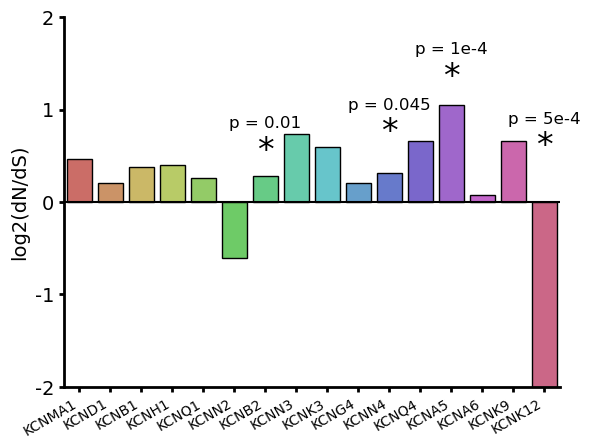

In [18]:
g = sns.barplot(y = np.log2(kcsorted["wmis_cv"]), x =  kcsorted["gene_name"], lw = 1, edgecolor = "k", palette = "hls")

g.set_xticklabels(g.get_xticklabels(), rotation = 30, ha = "right")
g.set_ylim(-2,2)
g.axhline(0, c = "k")

g.set_yticks([-2,-1,0,1,2])
g.set_yticklabels(g.get_yticks(), size = 14)

g.set_ylabel("log2(dN/dS)", size = 14)
g.set_xlabel("")

sns.despine()
g.annotate("p = 0.01", (6,0.8), size = 12, ha = "center")
g.annotate("*", (6,0.45), size = 24, ha = "center")

g.annotate("p = 0.045", (10,1.0), size = 12, ha = "center")
g.annotate("*", (10,0.65), size = 24, ha = "center")

g.annotate("p = 1e-4", (12,1.6), size = 12, ha = "center")
g.annotate("*", (12,1.25), size = 24, ha = "center")

g.annotate("p = 5e-4", (15,0.85), size = 12, ha = "center")
g.annotate("*", (15,0.5), size = 24, ha = "center")

for axis in ['top','bottom','left','right']:
    g.spines[axis].set_linewidth(2)
g.tick_params(width=2)

#plt.savefig("DNDS_KC_STAD_COSMIC_v2.pdf", bbox_inches = "tight")
plt.show()